<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 7</h1>

The aim of this exercise is to extend the Molecular Dynamics and Monte Carlo simulations developed in the previous exercises and study the thermodynamic and structural properties of a Lennard-Jones system. In particular, the analysis will include tail corrections for the potential energy and pressure, the study of statistical correlations and uncertainties through autocorrelation functions and data blocking, and the calculation of the radial distribution function $g(r)$.

The simulations will be performed for a Lennard-Jones system in the liquid phase, with reduced density $\rho^*=0.8$ and temperature $T^*=1.1$. Both Monte Carlo simulations in the NVT ensemble and Molecular Dynamics simulations in the NVE ensemble will be considered.

### Tail Corrections

In the previous simulations, the system was treated using **periodic boundary conditions** and the **minimum image convention**, together with a cutoff radius $r_c$. In this approximation, the Lennard-Jones potential is neglected for distances larger than the cutoff,

$$
V(r)=0 \qquad \text{for } r>r_c,
$$

which reduces the computational cost but introduces an approximation, since particles at larger distances can still contribute to the total energy and pressure.

To improve this approximation, **tail corrections** are introduced to account for the contribution of the interactions beyond the cutoff radius. In the `NSL_SIMULATOR` code, tail corrections have been implemented both for the **potential energy** and for the **pressure**.

The corrections are obtained by assuming that, for distances larger than the cutoff, the particles are approximately uncorrelated and therefore the radial distribution function can be approximated as

$$
g(r)\simeq1
\qquad \text{for } r>r_c.
$$

Under this assumption, the contributions of the neglected part of the Lennard-Jones potential can be integrated analytically. For the potential energy per particle, the resulting correction is

$$
\frac{V_{\mathrm{LJ}}^{\mathrm{tail}}}{N\epsilon}=8\pi\rho
\left[
\frac{1}{9r_c^9}
-\frac{1}{3r_c^3}
\right],
$$

while the corresponding correction to the pressure is

$$
\frac{w_{\mathrm{LJ}}^{\mathrm{tail}}}{3N\epsilon}
=32\pi\rho
\left[
\frac{1}{9r_c^9}
-\frac{1}{6r_c^3}
\right].
$$

Since the assumption $g(r)\simeq1$ is justified in the region beyond the cutoff, where correlations between particles are weak and the Lennard-Jones interaction is already small, the neglected contribution is relatively small. The tail corrections therefore provide a **minor but physically relevant correction** to the truncated-potential approximation, improving the estimate of the potential energy and pressure without significantly increasing the computational cost.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

file_path = "nsl_simulator/NSL_SIMULATOR/OUTPUT/instantaneous_potential_energy_MC_equil.dat"

T = np.loadtxt(
    "nsl_simulator/NSL_SIMULATOR/OUTPUT/instantaneous_temperature_MD_equil.dat",
    comments="#"
)

data = np.loadtxt(file_path, comments="#")

steps = np.arange(1, len(data) + 1)
potential_energy = data

### Simulation Setup and Equilibration

The simulations were performed using $N=108$ particles in the liquid phase, with reduced density $\rho^*=0.8$ and cutoff radius $r_c^*=2.5$. For the Molecular Dynamics simulation, a time step of $\Delta t^*=0.001$ was used, while the initial particle positions were arranged according to an **FCC lattice**.

A preliminary simulation of $10000$ steps was first performed for both Monte Carlo and Molecular Dynamics in order to study the equilibration process. The instantaneous potential energy was monitored in the Monte Carlo simulation, while the instantaneous temperature was monitored in the Molecular Dynamics simulation. These quantities were then plotted as a function of the number of steps to identify when the system reached a stable equilibrium regime.

Since the temperature is not a conserved quantity in the NVE Molecular Dynamics simulation, an initial temperature of $T^*=2$ was chosen in order to obtain an equilibrium temperature close to the target value $T^*=1.1$. For the Monte Carlo simulation, the amplitude of the proposed moves was set to $\Delta t^*=0.1$, yielding an acceptance rate of approximately $50\%$.

The analysis of the preliminary simulations showed that both systems reached equilibrium within the first part of the evolution. Therefore, an equilibration time of $2000$ steps was adopted for the subsequent simulations. After this equilibration phase, the simulations were restarted from the corresponding equilibrated configurations using the `RESTART` functionality of the NSL simulator, and a further $500000$ steps were performed for the actual data collection.

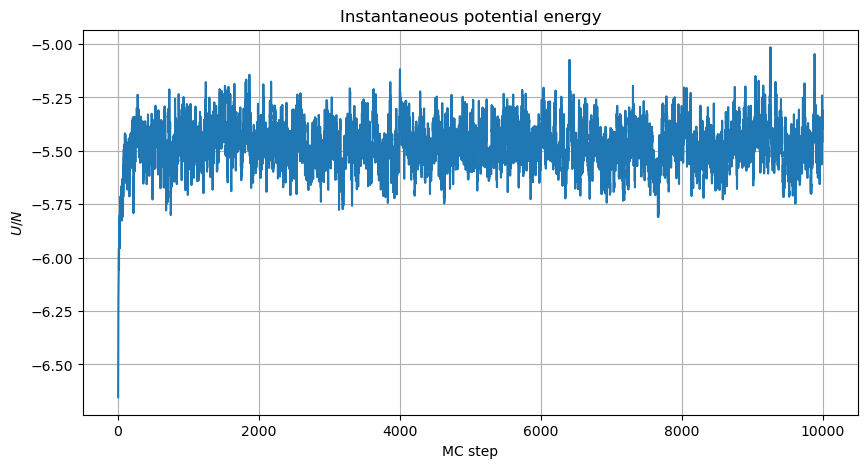

In [9]:
plt.figure(figsize=(10, 5))

plt.plot(steps, potential_energy)

plt.xlabel("MC step")
plt.ylabel(r"$U/N$")
plt.title("Instantaneous potential energy")

plt.grid()
plt.show()

**Figure 1:** Evolution of the instantaneous potential energy per particle during the preliminary Monte Carlo simulation used to assess the equilibration time. After an initial transient, the system reaches an equilibrium regime osscillating around $\sim 5.5$.

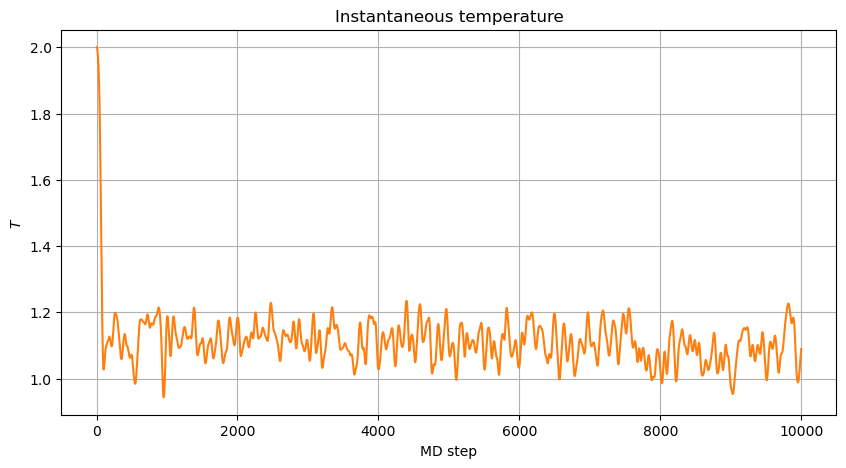

In [79]:
plt.figure(figsize=(10, 5))
plt.plot(steps, T, color='tab:orange',)
plt.xlabel("MD step")
plt.ylabel(r"$T$")
plt.title("Instantaneous temperature")
plt.grid()
plt.show()

**Figure 2:** Evolution of the instantaneous temperature during the preliminary Molecular Dynamics simulation. Starting from $T^*=2$, the temperature relaxes towards the equilibrium value close to the target temperature $T^*=1.1$, allowing the equilibration time to be estimated.

### Autocorrelation Function

The autocorrelation function measures the degree of statistical dependence between measurements of the same observable taken at different times. It is therefore useful for determining whether consecutive measurements can be considered statistically independent or whether they are correlated.

For a sequence of measurements $A_i$, the normalized autocorrelation function can be defined as

$$
\chi(k)=
\frac{
\displaystyle
\frac{1}{N-k}
\sum_{i=0}^{N-k-1}
(A_i-\overline{A})(A_{i+k}-\overline{A})
}{
\displaystyle
\left\langle A^2\right\rangle-
\left\langle A\right\rangle^2
}.
$$

By construction, $\chi(0)=1$, while for sufficiently large time separations the correlation progressively vanishes, so that $\chi(t)\rightarrow0$. The characteristic time over which the autocorrelation function decays provides an estimate of the **correlation time** of the observable.

In this exercise, the autocorrelation function was studied for the instantaneous potential energy per particle $U/N$ in both the Monte Carlo and Molecular Dynamics simulations. The first $10000$ measurements of $U/N$ were extracted from the simulation data and analyzed using Python.

The estimated correlation time is then used to determine a suitable block length for the **data blocking** method. In order for different blocks to provide approximately independent estimates, the block length $L$ should be chosen significantly larger than the correlation time. In this way, measurements belonging to different blocks are sufficiently separated in time, reducing the correlations between the corresponding block averages.

In [39]:
u_mc = np.loadtxt(
    "nsl_simulator/NSL_SIMULATOR/OUTPUT/instantaneous_potential_energy_MC.dat",
    comments="#"
)

u_md = np.loadtxt(
    "nsl_simulator/NSL_SIMULATOR/OUTPUT/instantaneous_potential_energy_MD.dat",
    comments="#"
)

u_md_ac = u_md[:10000]
u_mc_ac = u_mc[:10000]

In [22]:
def autocorrelation(data, max_lag):
    mean = np.mean(data)
    variance = np.mean((data - mean)**2)

    correlation = np.zeros(max_lag + 1)

    for k in range(max_lag + 1):
        correlation[k] = (
            np.sum((data[:len(data)-k] - mean)* (data[k:] - mean))/ (len(data) - k)) / variance

    return correlation

In [23]:
def plot_autocorrelation(lags, correlation, title="Autocorrelation function"):
    plt.figure(figsize=(10, 5))
    plt.plot(lags, correlation)
    plt.xlabel("Lag $k$")
    plt.ylabel(r"$C(k)$")
    plt.title(title)
    plt.grid()
    plt.show()

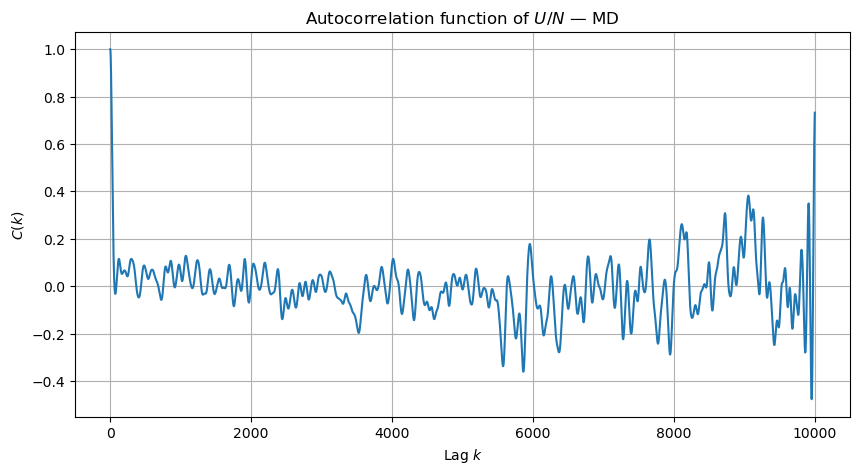

In [27]:
max_lag = 9999

acf_md = autocorrelation(u_md_ac, max_lag)

lags = np.arange(max_lag + 1)

plot_autocorrelation(
    lags,
    acf_md,
    title=r"Autocorrelation function of $U/N$ — MD"
)

**Figure 3.** Autocorrelation function of the instantaneous potential energy per particle $U/N$ for the Molecular Dynamics simulation. The initial decay characterizes the temporal correlation of the measurements, while the oscillations around zero at large lags arise from the increasing statistical uncertainty of the estimator.

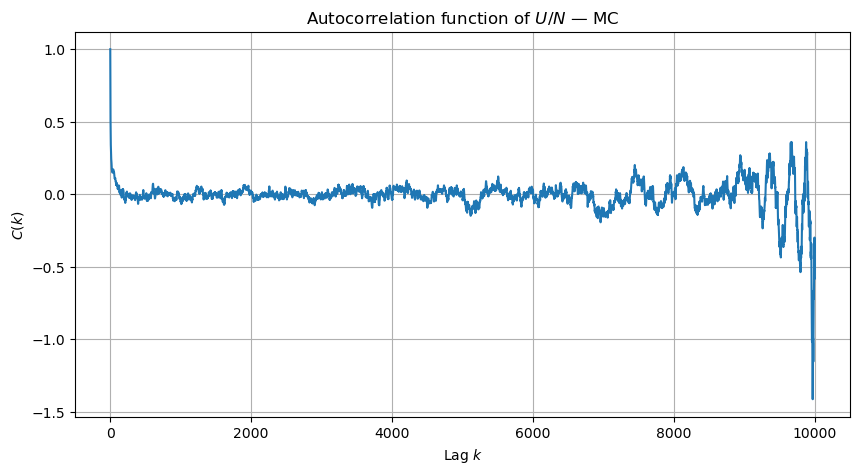

In [78]:
acf_mc = autocorrelation(u_mc_ac, max_lag)

plot_autocorrelation(
    lags,
    acf_mc,
    title=r"Autocorrelation function of $U/N$ — MC"
)

**Figure 4.** Autocorrelation function of the instantaneous potential energy per particle $U/N$ for the Monte Carlo simulation. The rapid initial decay indicates that the measurements become progressively decorrelated, while the fluctuations around zero at large lags are mainly due to statistical noise.

From the autocorrelation functions, a reasonable choice for the block length can be estimated to be approximately $L\sim 10^3$ steps per block, which is sufficiently larger than the characteristic correlation time of the observable.

### Data Blocking

To estimate the statistical uncertainty of the potential energy per particle $U/N$, the data blocking method was applied to the simulation results for different block lengths $L$. Since the total number of measurements is $M=500000$, the number of blocks is given by $N={M}/{L}.$

The uncertainty was evaluated for block lengths in the range

$$
L\in[10,5000].
$$

To obtain a sufficiently detailed sampling of this interval, $1000$ logarithmically spaced values of $L$ were generated in Python.

For each value of $L$, the corresponding block averages and statistical uncertainty of $U/N$ were calculated. The resulting uncertainties were then plotted as a function of the block length in order to identify the region where the uncertainty reaches a stable behaviour. This allows us to verify whether the previously estimated value of approximately $L\sim 10^3$ steps per block is sufficient to obtain statistically reliable and approximately independent block averages.

In [103]:
L_values = np.unique(
    np.logspace(np.log10(10),np.log10(5000), 1000).astype(int)
)

errors_md = []
averages_md = []

for L in L_values:
    average, error = data_blocking(u_md, L)

    averages_md.append(average)
    errors_md.append(error)

averages_md = np.array(averages)
errors_md = np.array(errors)

In [104]:
L_values = np.array(L_values)

In [105]:
L_values = np.unique(
    np.logspace(np.log10(10),np.log10(5000), 1000).astype(int)
)

errors_mc = []
averages_mc = []

for L in L_values:
    average, error = data_blocking(u_mc, L)

    averages_mc.append(average)
    errors_mc.append(error)

averages_mc = np.array(averages_mc)
errors_mc = np.array(errors_mc)

In [106]:
def plot_blocking_comparison(L_values, errors_md, errors_mc):
    plt.figure(figsize=(10, 5))

    plt.plot(L_values, errors_mc, label='MC')
    plt.plot(L_values, errors_md, label='MD')

    plt.xlabel(r"Block size $L$")
    plt.ylabel(r"Uncertainty $\sigma_{\langle U/N\rangle}$")
    plt.title(r"Data blocking: uncertainty vs block size")

    plt.legend()
    plt.grid()
    plt.show()

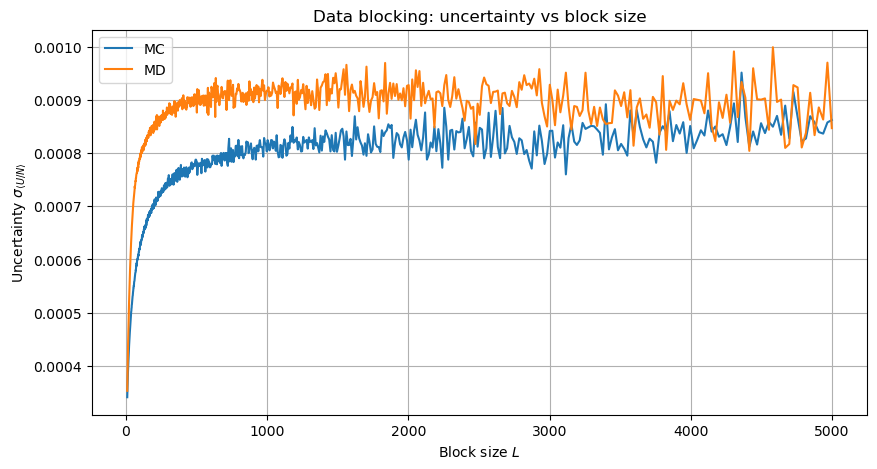

In [107]:
plot_blocking_comparison(
    L_values,
    errors_md,
    errors_mc
)

**Figure 5:** Statistical uncertainty of the potential energy per particle $U/N$ as a function of the block length $L$ for the Monte Carlo and Molecular Dynamics simulations. The uncertainty is initially small for short blocks and increases as $L$ grows, eventually reaching a stable behaviour around $L\approx1000$ steps per block.

The autocorrelation analysis showed that a block length of approximately $L=1000$ steps is already sufficient to reduce the correlations between measurements. However, for the final analysis, a more conservative value of $L=5000$ steps per block was adopted. With $M=500000$ total measurements, this corresponds to $N=100$ blocks, which is still a sufficiently large number to obtain reliable estimates of the statistical uncertainties. The larger block size therefore provides an additional margin with respect to the estimated correlation time, while maintaining an adequate number of statistically independent blocks for the data blocking analysis.

### Radial Distribution Function

The **radial distribution function** $g(r)$, or pair distribution function, is an important quantity for describing the microscopic structure of a fluid. It represents the probability of finding a particle at a distance $r$ from a reference particle, relative to the probability expected for an ideal gas at the same density.

For a homogeneous and isotropic system, the radial distribution function depends only on the distance $r$ between two particles. In an ideal gas, where particles are completely uncorrelated, one has

$$
g(r)=1.
$$

For an interacting system, deviations from unity describe the spatial correlations induced by the interparticle potential. In particular, for a Lennard-Jones liquid, one expects $g(r)\simeq0$ at very short distances due to the strong repulsive interaction, followed by a first peak corresponding to the most probable nearest-neighbour distance. At larger distances, the oscillations become progressively weaker and $g(r)$ approaches unity, indicating that the correlations between particles become negligible.

### Implementation of the Radial Distribution Function

The radial distribution function was implemented using a **histogram method**. At each measurement step, all distinct pairs of particles $i<j$ were considered and their mutual distance was calculated using the **periodic boundary conditions** and the minimum image convention.

The pair distances were considered only within

$$
r<\frac{L}{2},
$$

where $L$ is the side of the simulation box. The interval was divided into bins of width $\Delta r$, and each pair was assigned to the corresponding bin according to its distance.

Since the code considers only pairs with $i<j$, each pair is counted once. The resulting histogram is then normalized by the number of particles, the number density $\rho$, and the volume of the spherical shell associated with each bin.

For a bin centered at $r$, the shell volume is calculated as

$$
\Delta V=
\frac{4\pi}{3}
\left[
\left(r+\frac{\Delta r}{2}\right)^3-
\left(r-\frac{\Delta r}{2}\right)^3
\right].
$$

The radial distribution function is therefore obtained from the histogram count according to

$$
g(r)=
\frac{2\,H(r)}
{N\rho\,\Delta V},
$$

where $H(r)$ is the number of particle pairs accumulated in the corresponding bin. The factor 2 accounts for the fact that each pair is counted only once in the histogram, whereas the definition of $g(r)$ considers both particles of each pair as possible reference particles.

The histogram was accumulated during the simulation and normalized at the end of each measurement. The resulting values of $g(r)$ were then averaged over the blocks, and the final radial distribution function together with its statistical uncertainty was written to the output file.


### Results of the Simulations

The simulations considered Argon modeled through a Lennard--Jones potential with parameters $\sigma=0.34\,\mathrm{nm}$, $\epsilon/k_B=120\,\mathrm{K}$, and $m=39.948\,\mathrm{amu}$.

The simulations were carried out in the **liquid phase**, at reduced density $\rho^*=0.8$ and temperature $T^*=1.1$, with a cutoff radius $r_c^*=2.5$. Both Monte Carlo (NVT ensemble) and Molecular Dynamics (NVE ensemble) simulations were equilibrated as described in the previous sections.

To estimate the statistical uncertainties, the **data blocking method** was applied using a block length of $L=5000$ steps.

The following figure reports the results for the **average potential energy per particle** $U/N$, the **pressure** $P$, and the **radial distribution function** $g(r)$, comparing Monte Carlo and Molecular Dynamics simulations under the same thermodynamic conditions.

### Pressure in Molecular Dynamics and Monte Carlo

In Molecular Dynamics (MD) simulations, the pressure is computed using the standard virial expression

$$
P = \rho \frac{2}{3}\langle K \rangle+ \frac{1}{V}
\left(
P_{\mathrm{tail}}N + \frac{48}{3}\langle \mathrm{virial} \rangle
\right),
$$

where the first term represents the kinetic contribution, related to the average kinetic energy per particle, while the second term accounts for the contribution of the interparticle forces. The corresponding tail correction is also included in the calculation.

In Monte Carlo (MC) simulations, velocities are not defined and the kinetic energy cannot therefore be computed directly. For this reason, the kinetic contribution is replaced by the ideal-gas term $\rho T$, which corresponds to the appropriate ensemble average in the canonical ensemble. The resulting pressure is therefore calculated as

$$
P = \rho T + \frac{1}{V}
\left(
P_{\mathrm{tail}}N + \frac{48}{3}\langle \mathrm{virial} \rangle
\right).
$$

This formulation allows the pressure to be evaluated consistently in both simulations, despite the different dynamical variables available in the NVT Monte Carlo and NVE Molecular Dynamics ensembles.

In [74]:
def plot_comparison(file_mc, file_md, ylabel, title):
    """
    Plot the progressive average and its uncertainty
    for MC and MD simulations.
    """

    data_mc = np.loadtxt(file_mc, comments='#')
    data_md = np.loadtxt(file_md, comments='#')

    block_mc = data_mc[:, 0]
    average_mc = data_mc[:, 2]
    error_mc = data_mc[:, 3]

    block_md = data_md[:, 0]
    average_md = data_md[:, 2]
    error_md = data_md[:, 3]

    plt.figure(figsize=(8, 5))

    plt.errorbar(
        block_mc,
        average_mc,
        yerr=error_mc,
        label='MC',
        linewidth=1
    )

    plt.errorbar(
        block_md,
        average_md,
        yerr=error_md,
        label='MD',
        linewidth=1
    )

    plt.xlabel('Block')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_gofr(file_mc, file_md):
    """
    Plot the radial distribution function g(r)
    for MC and MD simulations in two separate figures.
    """

    data_mc = np.loadtxt(file_mc, comments='#')
    data_md = np.loadtxt(file_md, comments='#')

    r_mc = data_mc[:, 0]
    g_mc = data_mc[:, 1]
    error_mc = data_mc[:, 2]

    r_md = data_md[:, 0]
    g_md = data_md[:, 1]
    error_md = data_md[:, 2]

    # MC
    plt.figure(figsize=(8, 5))

    plt.fill_between(
        r_mc,
        0,
        g_mc,
        alpha=0.25,
        color='tab:orange'
    )

    plt.errorbar(
        r_mc,
        g_mc,
        yerr=error_mc,
        color='tab:orange',
        label='MC',
        linewidth=1
    )

    plt.xlabel(r'$r$')
    plt.ylabel(r'$g(r)$')
    plt.title('Radial distribution function - MC')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # MD
    plt.figure(figsize=(8, 5))

    plt.fill_between(
        r_md,
        0,
        g_md,
        alpha=0.25,
        color='tab:blue'
    )

    plt.errorbar(
        r_md,
        g_md,
        yerr=error_md,
        color='tab:blue',
        label='MD',
        linewidth=1
    )

    plt.xlabel(r'$r$')
    plt.ylabel(r'$g(r)$')
    plt.title('Radial distribution function - MD')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

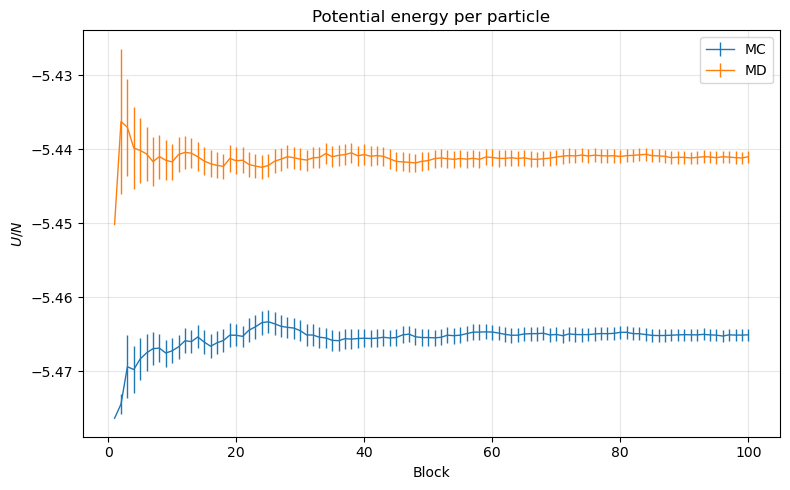

In [75]:
# Potential energy
plot_comparison(
    'nsl_simulator/NSL_SIMULATOR/OUTPUT/potential_energy_MC.dat',
    'nsl_simulator/NSL_SIMULATOR/OUTPUT/potential_energy_MD.dat',
    r'$U/N$',
    'Potential energy per particle'
)

**Figure 6.** Average potential energy per particle $U/N$ as a function of the number of blocks for the Monte Carlo (MC) and Molecular Dynamics (MD) simulations. The two methods lead to equilibrium values that are close to each other, showing good agreement between the NVT and NVE ensembles for this observable.

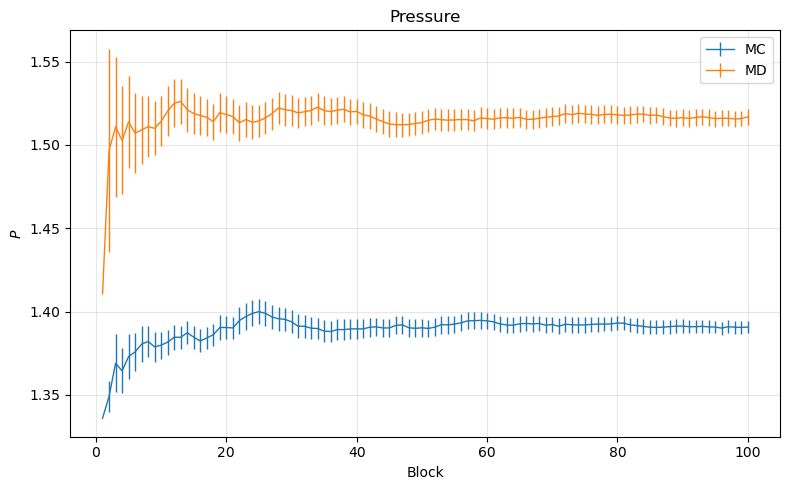

In [76]:
# Pressure
plot_comparison(
    'nsl_simulator/NSL_SIMULATOR/OUTPUT/pressure_MC.dat',
    'nsl_simulator/NSL_SIMULATOR/OUTPUT/pressure_MD.dat',
    r'$P$',
    'Pressure'
)

**Figure 7.** Average pressure $P$ as a function of the number of blocks for the Monte Carlo (MC) and Molecular Dynamics (MD) simulations. The equilibrium values obtained with the two methods are close to each other, indicating good agreement between the pressure estimates in the NVT and NVE ensembles.

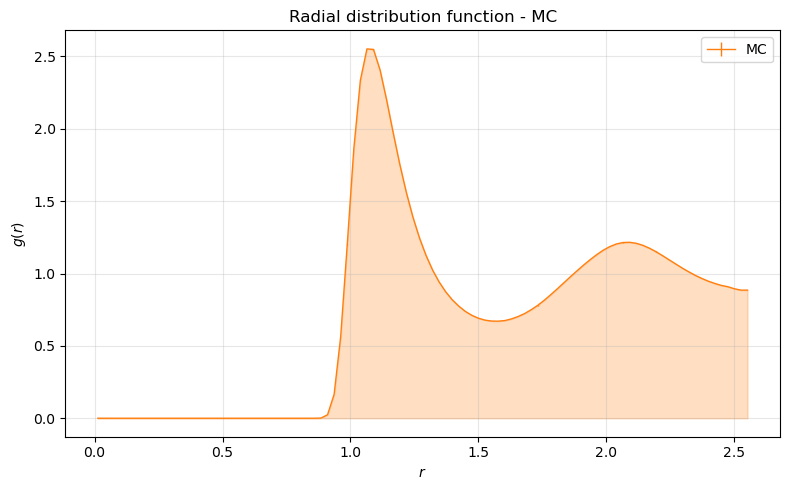

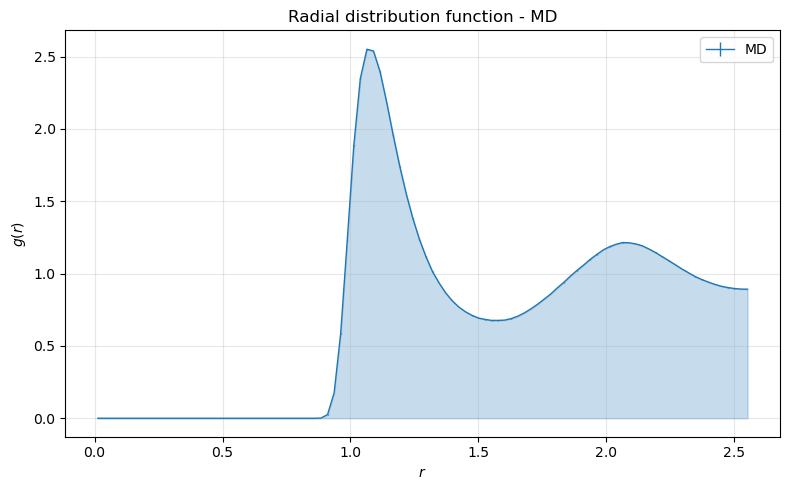

In [77]:
# Radial distribution function
plot_gofr(
    'nsl_simulator/NSL_SIMULATOR/OUTPUT/gofr_final_MC.dat',
    'nsl_simulator/NSL_SIMULATOR/OUTPUT/gofr_final_MD.dat'
)

**Figure 8.** Radial distribution function $g(r)$ obtained from the Monte Carlo (MC) and Molecular Dynamics (MD) simulations. The two methods show a very similar spatial correlation pattern, with the characteristic short-range structure expected for a Lennard--Jones liquid. In particular, the strong suppression at short distances and the subsequent oscillations around unity are consistent with the theoretical behaviour of $g(r)$, with the correlations progressively decreasing at larger distances.

The overall agreement between the two methods is consistent with the expectation that the NVT and NVE ensembles provide the same equilibrium averages for macroscopic observables in the thermodynamic limit. The close correspondence observed for $U/N$, $P$, and $g(r)$ therefore indicates that both simulation methods reproduce the equilibrium properties of the Lennard--Jones liquid under the considered thermodynamic conditions.